In [ ]:
!nvidia-smi

In [ ]:
!pip install bitsandbytes transformers accelerate -q

In [ ]:
!pip install --upgrade peft -q

In [ ]:
!pip install git+https://github.com/huggingface/diffusers.git -q

In [ ]:
!wget https://raw.githubusercontent.com/huggingface/diffusers/main/examples/dreambooth/train_dreambooth_lora_sdxl.py

In [ ]:
import os
from google.colab import files

local_dir = "./dog/"
os.makedirs(local_dir)
os.chdir(local_dir)

uploaded_images = files.upload()
os.chdir("/content")

In [ ]:
# from huggingface_hub import snapshot_download

# local_dir = "./dog/"
# snapshot_download(
#     "diffusers/dog-example",
#     local_dir=local_dir, repo_type="dataset",
#     ignore_patterns=".gitattributes",
# )

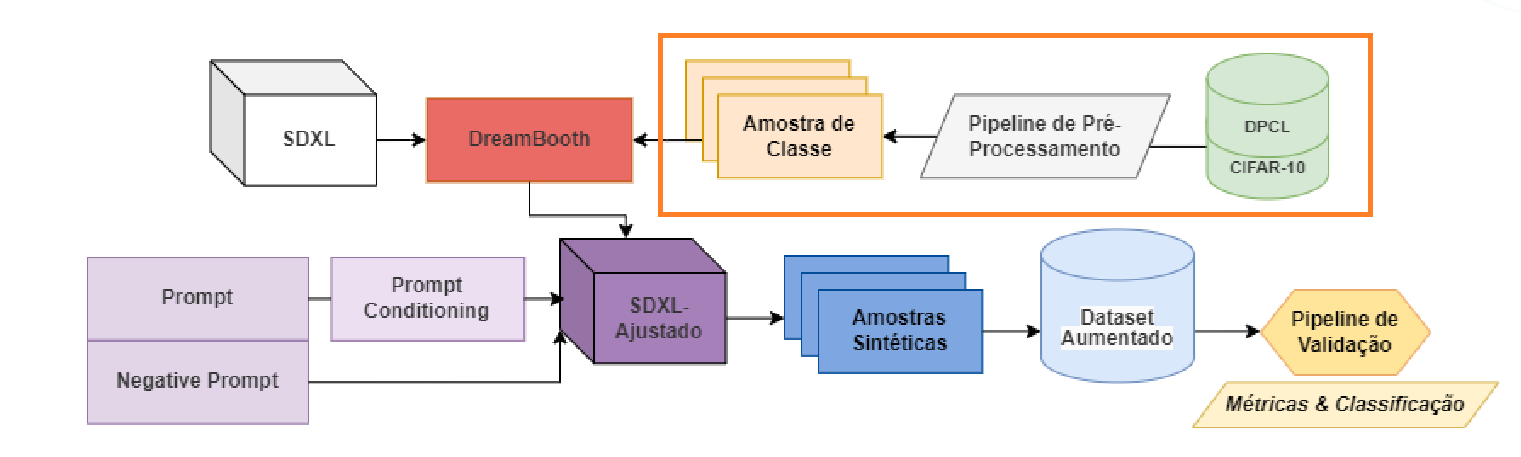

In [ ]:
#@title Pré-processamento

from PIL import Image

def image_grid(imgs, rows, cols, resize=256):

    if resize is not None:
        imgs = [img.resize((resize, resize)) for img in imgs]
    w, h = imgs[0].size
    grid = Image.new("RGB", size=(cols * w, rows * h))
    grid_w, grid_h = grid.size

    for i, img in enumerate(imgs):
        grid.paste(img, box=(i % cols * w, i // cols * h))
    return grid

In [ ]:
import glob

img_paths = "./dog/*.jpeg"
imgs = [Image.open(path) for path in glob.glob(img_paths)]

num_imgs_to_preview = 5
image_grid(imgs[:num_imgs_to_preview], 1, num_imgs_to_preview)

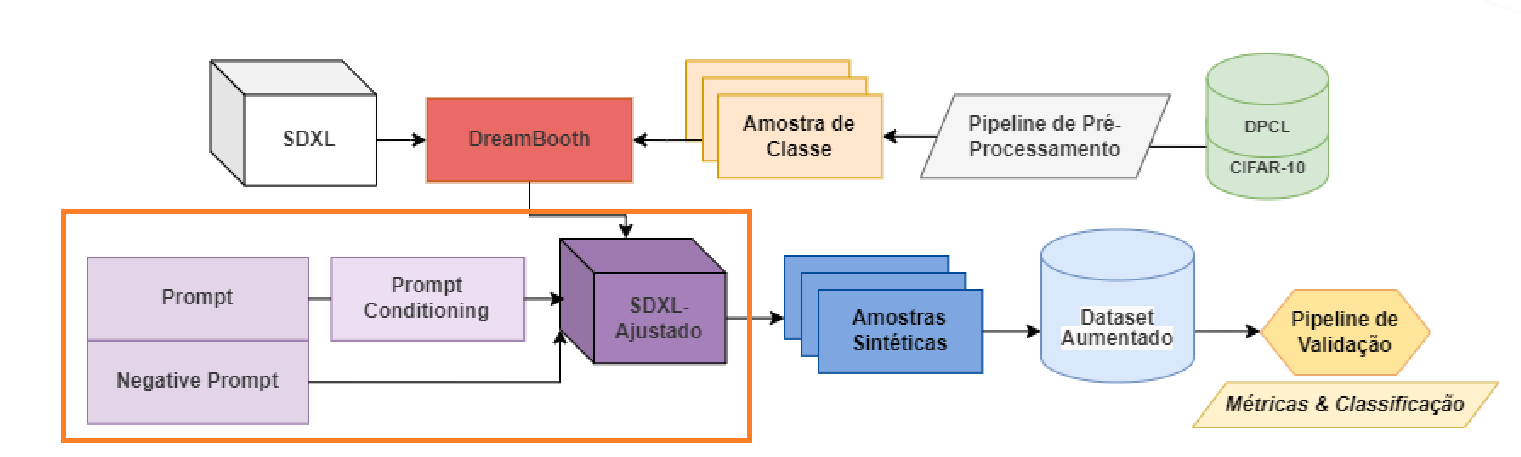

In [ ]:
#@title Rotulagem e geração de prompt

import requests
from transformers import AutoProcessor, BlipForConditionalGeneration
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

blip_processor = AutoProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
blip_model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base",torch_dtype=torch.float16).to(device)

def caption_images(input_image):
    inputs = blip_processor(images=input_image, return_tensors="pt").to(device, torch.float16)
    pixel_values = inputs.pixel_values

    generated_ids = blip_model.generate(pixel_values=pixel_values, max_length=50)
    generated_caption = blip_processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
    return generated_caption

In [ ]:
import glob
from PIL import Image

local_dir = "./dog/"
imgs_and_paths = [(path,Image.open(path)) for path in glob.glob(f"{local_dir}*.jpeg")]

In [ ]:
import json

caption_prefix = "a photo of PAVIC dog, "
with open(f'{local_dir}metadata.jsonl', 'w') as outfile:
  for img in imgs_and_paths:
      caption = caption_prefix + caption_images(img[1]).split("\n")[0]
      entry = {"file_name":img[0].split("/")[-1], "prompt": caption}
      json.dump(entry, outfile)
      outfile.write('\n')

In [ ]:
import gc

del blip_processor, blip_model
gc.collect()
torch.cuda.empty_cache()

In [ ]:
import locale
locale.getpreferredencoding = lambda: "UTF-8"

!accelerate config default

In [ ]:
from huggingface_hub import notebook_login
notebook_login()

In [ ]:
!pip install datasets -q

 - Use `--output_dir` to specify your LoRA model repository name!
 - Use `--caption_column` to specify name of the cpation column in your dataset. In this example we used "prompt" to
 save our captions in the
 metadata file, change this according to your needs.

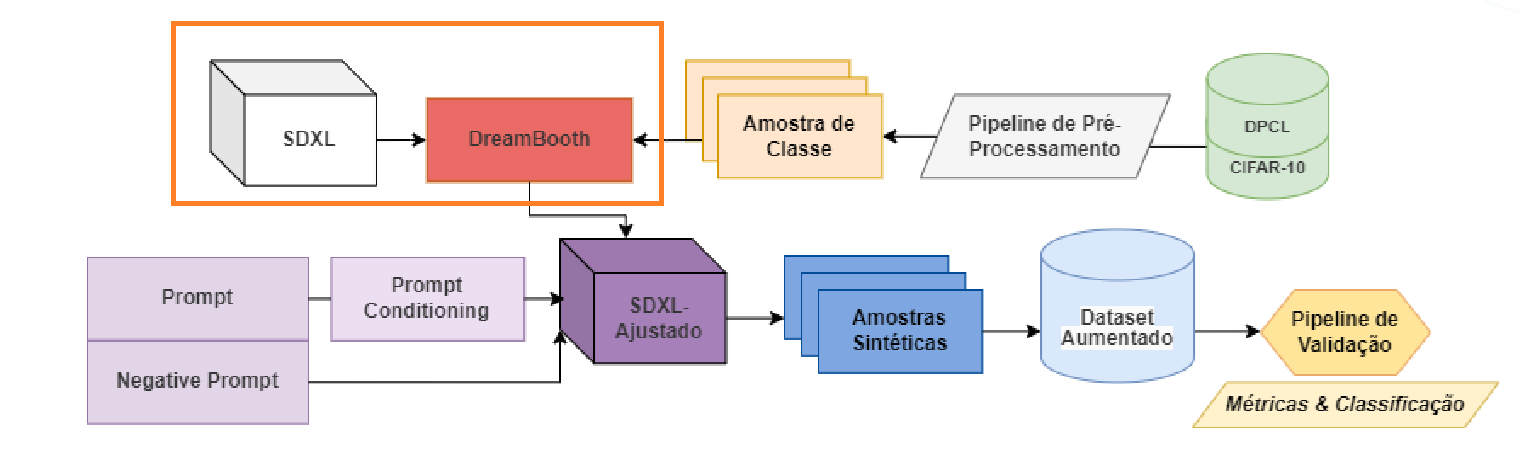

In [ ]:
#@title Hyperparameter tuning

#!/usr/bin/env bash
!accelerate launch train_dreambooth_lora_sdxl.py \
  --pretrained_model_name_or_path="stabilityai/stable-diffusion-xl-base-1.0" \
  --pretrained_vae_model_name_or_path="madebyollin/sdxl-vae-fp16-fix" \
  --dataset_name="dog" \
  --output_dir="golden_dog_LoRA" \
  --caption_column="prompt"\
  --mixed_precision="fp16" \
  --instance_prompt="a photo of TOK dog" \
  --resolution=1024 \
  --train_batch_size=1 \
  --gradient_accumulation_steps=3 \
  --gradient_checkpointing \
  --learning_rate=1e-4 \
  --snr_gamma=5.0 \
  --lr_scheduler="constant" \
  --lr_warmup_steps=0 \
  --mixed_precision="fp16" \
  --use_8bit_adam \
  --max_train_steps=500 \
  --checkpointing_steps=717 \
  --seed="0"

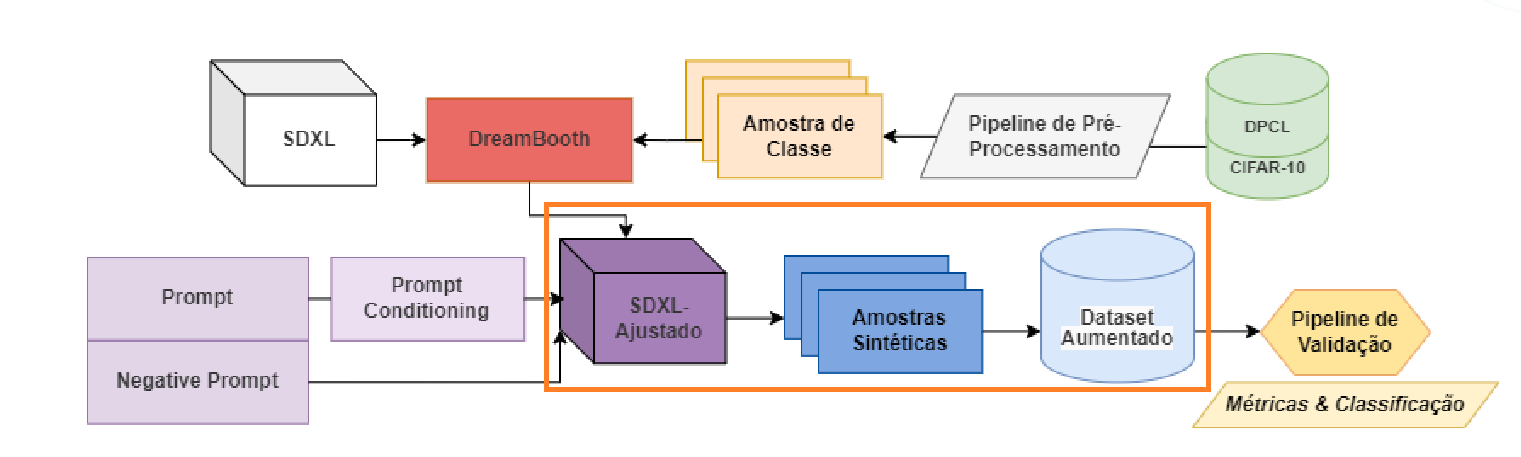

In [ ]:
from huggingface_hub import whoami
from pathlib import Path
output_dir = "golden_dog_LoRA"
username = whoami(token=Path("/root/.cache/huggingface/"))["name"]
repo_id = f"{username}/{output_dir}"

In [ ]:

from train_dreambooth_lora_sdxl import save_model_card
from huggingface_hub import upload_folder, create_repo

repo_id = create_repo(repo_id, exist_ok=True).repo_id

save_model_card(
    repo_id = repo_id,
    use_dora=False,
    images=[],
    base_model="stabilityai/stable-diffusion-xl-base-1.0",
    train_text_encoder=False,
    instance_prompt="a photo of PAVIC dog",
    validation_prompt=None,
    repo_folder=output_dir,
    vae_path="madebyollin/sdxl-vae-fp16-fix",
)

upload_folder(
    repo_id=repo_id,
    folder_path=output_dir,
    commit_message="End of training",
    ignore_patterns=["step_*", "epoch_*"],
)

In [ ]:
from IPython.display import display, Markdown

link_to_model = f"https://huggingface.co/{repo_id}"
display(Markdown("### O modelo foi modelo treinado.\nAccesso em: {}".format(link_to_model)))

In [ ]:
import torch
from diffusers import DiffusionPipeline, AutoencoderKL

vae = AutoencoderKL.from_pretrained("madebyollin/sdxl-vae-fp16-fix", torch_dtype=torch.float16)
pipe = DiffusionPipeline.from_pretrained(
    "stabilityai/stable-diffusion-xl-base-1.0",
    vae=vae,
    torch_dtype=torch.float16,
    variant="fp16",
    use_safetensors=True
)
pipe.load_lora_weights(repo_id)
_ = pipe.to("cuda")

In [ ]:
prompt = "a photo of PAVIC dog in a bucket at the beach"

image = pipe(prompt=prompt, num_inference_steps=25).images[0]
image

In [ ]:

!pip install bitsandbytes transformers accelerate -q
!pip install --upgrade peft -q
!pip install git+https://github.com/huggingface/diffusers.git -q


In [ ]:
# !pip install datasets


In [ ]:
!wget http://cs231n.stanford.edu/tiny-imagenet-200.zip
!unzip -q tiny-imagenet-200.zip -d /content/tiny-imagenet


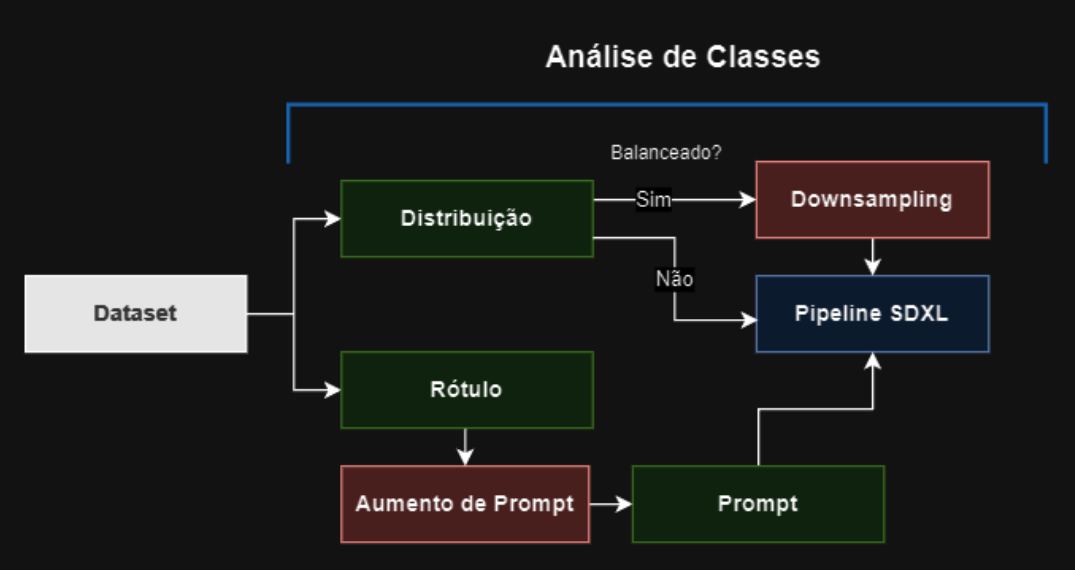

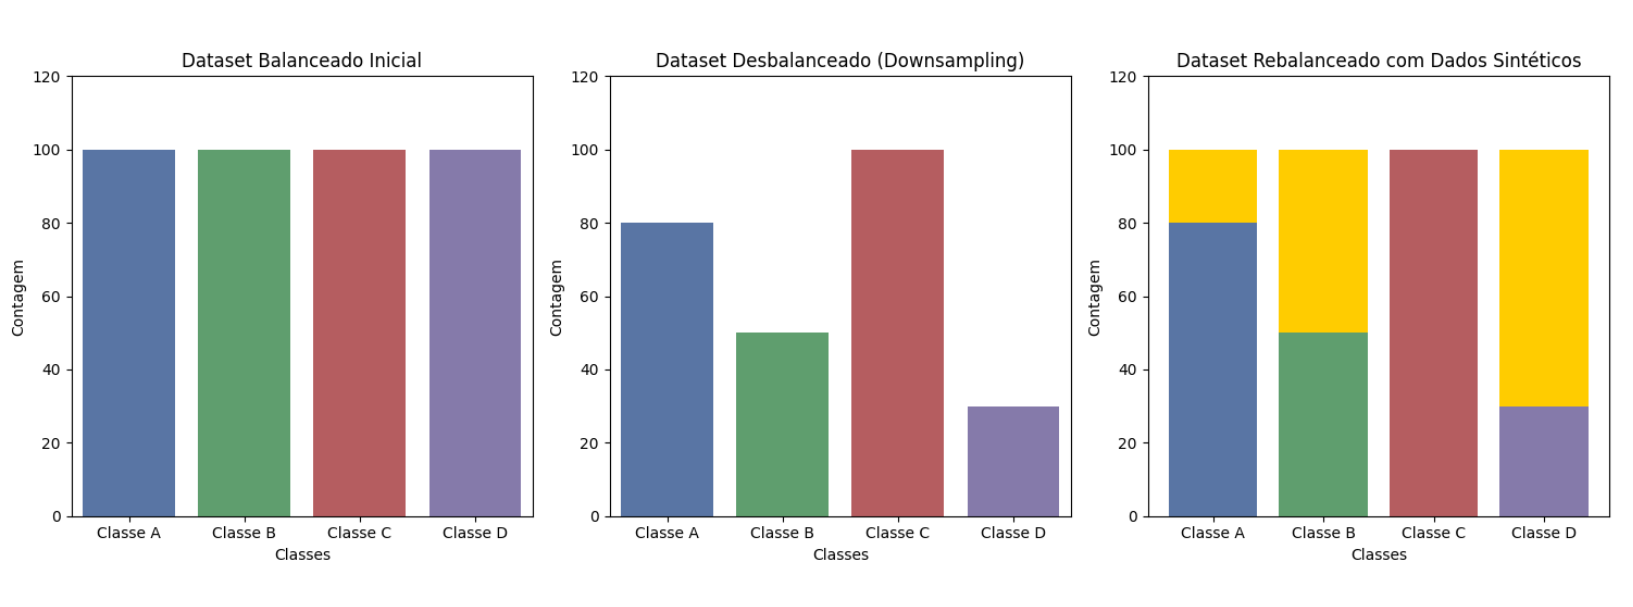

In [ ]:
import os
from collections import Counter

train_path = '/content/tiny-imagenet/tiny-imagenet-200/train'

classes = os.listdir(train_path)

class_counts = {}
for class_name in classes:
    class_dir = os.path.join(train_path, class_name, 'images')
    num_images = len(os.listdir(class_dir))
    class_counts[class_name] = num_images

print("Contagem de imagens por classe:")
for class_name, count in class_counts.items():
    print(f"Classe {class_name}: {count} imagens")


In [ ]:
import matplotlib.pyplot as plt

counts = list(class_counts.values())
classes_list = list(class_counts.keys())

plt.figure(figsize=(14, 6))
plt.bar(range(len(classes_list)), counts, color='skyblue')
plt.xlabel('Classes')
plt.ylabel('Número de Imagens')
plt.title('Distribuição de Imagens por Classe no Tiny ImageNet')
plt.show()


In [ ]:
min_count = 500
classes_to_balance = [class_name for class_name, count in class_counts.items() if count < min_count]

print("Classes que precisam de balanceamento:")
print(classes_to_balance)


In [ ]:
balance_requirements = {class_name: min_count - class_counts[class_name] for class_name in classes_to_balance}

print("Classes e número de imagens adicionais necessárias para balanceamento:")
for class_name, additional_images in balance_requirements.items():
    print(f"Classe {class_name}: {additional_images} imagens adicionais")


In [ ]:
import random
import os

def introduce_random_imbalance(dataset_path, imbalance_fraction=0.3, min_reduction=0.2, max_reduction=0.7):

    classes = os.listdir(dataset_path)

    num_classes_to_reduce = int(len(classes) * imbalance_fraction)
    classes_to_reduce = random.sample(classes, num_classes_to_reduce)

    classes_reduced = {}

    for class_name in classes_to_reduce:
        class_dir = os.path.join(dataset_path, class_name, 'images')
        images = os.listdir(class_dir)

        reduction_factor = random.uniform(min_reduction, max_reduction)
        num_images_to_keep = int(len(images) * reduction_factor)

        images_to_keep = random.sample(images, num_images_to_keep)

        for img in images:
            if img not in images_to_keep:
                os.remove(os.path.join(class_dir, img))

        classes_reduced[class_name] = num_images_to_keep
        print(f"Classe '{class_name}' reduzida para {num_images_to_keep} imagens (Redução: {reduction_factor:.2f}).")

    classes_unchanged = set(classes) - set(classes_to_reduce)
    print("\nClasses mantidas inalteradas:")
    print(list(classes_unchanged))

    return classes_reduced

dataset_path = '/content/tiny-imagenet/tiny-imagenet-200/train'
classes_reduced = introduce_random_imbalance(dataset_path, imbalance_fraction=0.3, min_reduction=0.2, max_reduction=0.7)


In [ ]:
def plot_class_distribution(classes_reduced, dataset_path):

    classes = os.listdir(dataset_path)

    class_counts = {}

    for class_name in classes:
        class_dir = os.path.join(dataset_path, class_name, 'images')
        num_images = len(os.listdir(class_dir))
        class_counts[class_name] = num_images

    classes_list = list(class_counts.keys())
    counts = list(class_counts.values())

    plt.figure(figsize=(14, 6))
    plt.bar(classes_list, counts, color='skyblue')
    plt.xlabel('Classes')
    plt.ylabel('Número de Imagens')
    plt.title('Distribuição de Imagens por Classe após Desbalanceamento')
    plt.xticks(rotation=90)
    plt.show()

plot_class_distribution(classes_reduced, dataset_path)


In [ ]:
import os
from diffusers import DiffusionPipeline

def load_and_prepare_imagenet(dataset_path):
    classes = [d for d in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, d))]
    class_image_paths = {cls: [os.path.join(dataset_path, cls, img) for img in os.listdir(os.path.join(dataset_path, cls))]
                         for cls in classes}
    return class_image_paths


In [ ]:

def fine_tune_dreambooth_for_class(class_name, image_paths, model_path="path/to/pretrained/model", output_dir="output/models"):

    pipeline = DiffusionPipeline.from_pretrained(model_path)
    pipeline.save_pretrained(f"{output_dir}/{class_name}")

    # pipeline.train(image_paths)


In [ ]:

def generate_samples_for_class(class_name, output_dir="output/models", num_samples=100):
=
    pipeline = DiffusionPipeline.from_pretrained(f"{output_dir}/{class_name}")

    synthetic_images = []
    for _ in range(num_samples):
        image = pipeline()
        synthetic_images.append(image)
=        # image.save(f"{output_dir}/{class_name}/synthetic_{_}.png")
    return synthetic_images


In [ ]:

def fine_tune_and_generate_for_imagenet(dataset_path, model_path, output_dir, num_samples_per_class=100):
    class_image_paths = load_and_prepare_imagenet(dataset_path)

    for class_name, image_paths in class_image_paths.items():
        print(f"Treinando o modelo para a classe: {class_name}")
        fine_tune_dreambooth_for_class(class_name, image_paths, model_path, output_dir)

        print(f"Gerando amostras para a classe: {class_name}")
        generate_samples_for_class(class_name, output_dir, num_samples_per_class)


In [ ]:

# Exemplo de uso com subset do ImageNet
dataset_path = "path/to/imagenet_subset"
model_path = "path/to/pretrained/model"
output_dir = "output"

fine_tune_and_generate_for_imagenet(dataset_path, model_path, output_dir)


In [ ]:
def calculate_iterations(dataset_path, batch_size):

    classes = [d for d in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, d))]
    num_classes = len(classes)

    num_iterations = (num_classes + batch_size - 1) // batch_size
    return num_iterations

dataset_path = "/content/tiny-imagenet/tiny-imagenet-200/train"
batch_size = 20

num_iterations = calculate_iterations(dataset_path, batch_size)
print(f"Número de iterações necessárias: {num_iterations}")


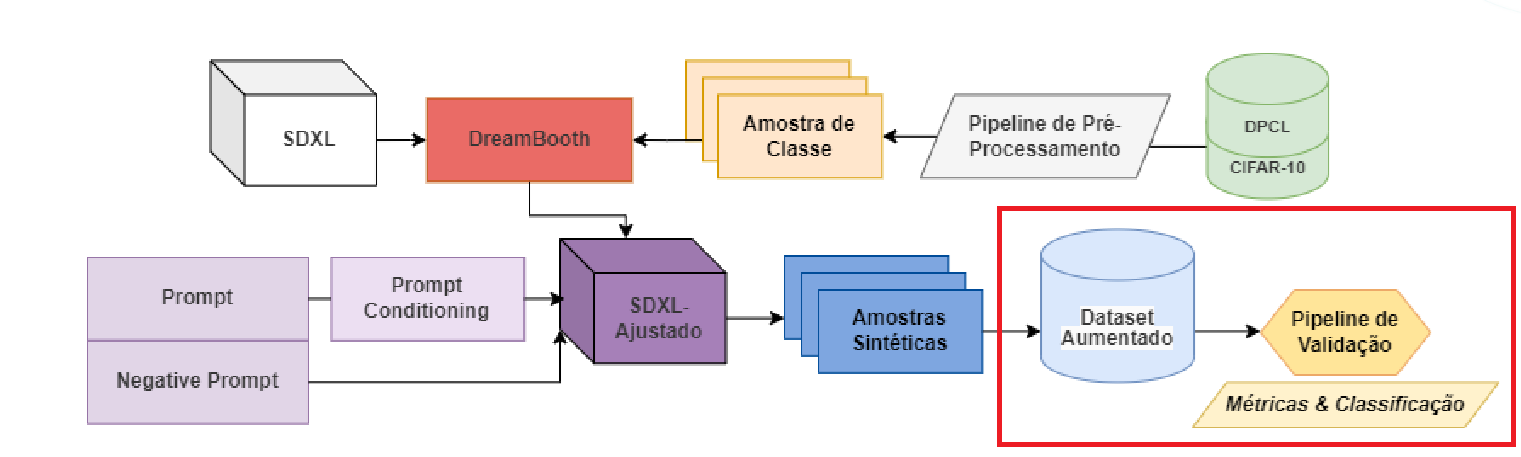